In [1]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

class_names = ['airplane', 'automobile', 'bird', 'cat','deer', 
               'dog', 'frog', 'horse','ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1692s 10us/step
(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


In [19]:
class_names = ['airplane', 'automobile', 'bird', 'cat','deer', 
               'dog', 'frog', 'horse','ship', 'truck']
print(y_train[0])
print(class_names[y_train[0][0]])

[6]
frog


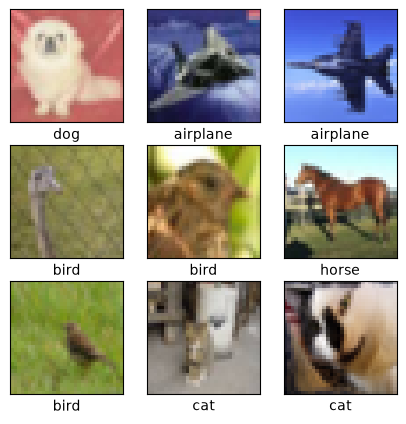

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(777)
sample_size = 9
random_idx = np.random.randint(50000, size=sample_size) # 0 ~ 49999 가지의 수중 9개 선택
plt.figure(figsize = (5, 5)) #이미지 크기
for i, idx in enumerate(random_idx):  #임의의 수 9개. i:0번~8번 인덱스, idx:임의의 수
    plt.subplot(3, 3, i+1)  #3행3열 i+1:순번
    plt.xticks([])  #x축 레이블 없음
    plt.yticks([])  #y축 레이블 없음
    plt.imshow(x_train[idx], cmap = 'gray') #이미지 출력
    plt.xlabel(class_names[y_train[idx][0]]) #x축 라벨
plt.show()

In [ ]:
"""모델 구성하기"""
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten
from tensorflow.keras.optimizers import Adam
model = Sequential()
'''
input_shape = (32, 32, 3) : 이미지의 크기 
padding = 'same' : 결과가 3행3열 유지. 가장자리를 0으로 채움. 출력이 입력과 같은 크기
kernel_size = 3 : 3행3열의 필터를 이용하여 가중치 계산
filters = 32 : 32개의 필터가 이미지의 특징맵을 생성
'''
model.add(Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu',\
                 input_shape = (32, 32, 3)))
# 가중치 갯수 : (3 * 3 * 3 + 1(편향)) * 32 = 896
model.add(Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu'))
# 가중치 갯수 : (3 * 3 * 32 + 1) * 32 = 9248
''' 
   해상도를 반으로 줄임
'''
model.add(MaxPool2D(pool_size = (2, 2), strides = 2, padding = 'same'))
model.add(Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(MaxPool2D(pool_size = (2, 2), strides = 2, padding = 'same'))
model.add(Conv2D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(Conv2D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(MaxPool2D(pool_size = (2, 2), strides = 2, padding = 'same'))
model.add(Flatten())  #1차원배열로 변경
model.add(Dense(256, activation = 'relu'))
model.add(Dense(10, activation = 'softmax')) #출력층

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,442,368 (9.32 MB)

 Trainable params: 814,122 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,628,246 (6.21 MB)

In [ ]:
'''
 optimizer = Adam(1e-4) : 기본값 1e-3. 학습률 10배 작게 설정. 천천히 수렴함. 학습횟수(epochs)늘려야 함.
                          학습률이 큰 경우는 발산가능성이 있음.
 loss = 'sparse_categorical_crossentropy' : 손실함수. 
          categorical_crossentropy : 출력값이 원핫인코딩된 경우 사용
          sparse_categorical_crossentropy : 원핫인코딩이 안된 경우 사용
'''
model.compile(optimizer = Adam(1e-4),loss = 'sparse_categorical_crossentropy',
              metrics = ['acc'])

history = model.fit(x_train, y_train, epochs = 5,batch_size = 32, validation_split=0.25)

Epoch 1/5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - acc: 0.4361 - loss: 1.6083 - val_acc: 0.5124 - val_loss: 1.3738
Epoch 2/5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - acc: 0.5802 - loss: 1.1928 - val_acc: 0.6017 - val_loss: 1.1380
Epoch 3/5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - acc: 0.6474 - loss: 1.0041 - val_acc: 0.6410 - val_loss: 1.0470
Epoch 4/5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 42s 36ms/step - acc: 0.6998 - loss: 0.8594 - val_acc: 0.6715 - val_loss: 0.9755
Epoch 5/5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 46s 39ms/step - acc: 0.7472 - loss: 0.7274 - val_acc: 0.6778 - val_loss: 0.9581


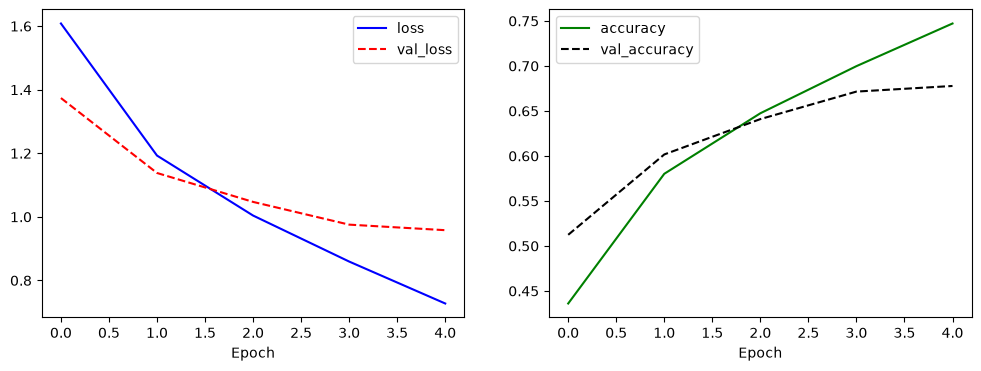

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'b-', label='loss')
plt.plot(history.history['val_loss'], 'r--', label='val_loss')
plt.xlabel('Epoch')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['acc'], 'g-', label='accuracy')
plt.plot(history.history['val_acc'], 'k--', label='val_accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()


In [11]:

model.evaluate(x_test,y_test) 

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - acc: 0.6726 - loss: 0.9643


[0.9642756581306458, 0.6725999712944031]

In [ ]:
model.save('cifar10_model.h5') # 학습된 모델을 저장

In [2]:
#cifar10_model.h5 이 파일을 읽어서 모델에 적용하기
# 파이썬데이터를 초기화하기
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

class_names = ['airplane', 'automobile', 'bird', 'cat','deer', 
               'dog', 'frog', 'horse','ship', 'truck']

(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


In [3]:
from keras.models import load_model

model = load_model('cifar10_model.h5')

In [4]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.6726 - loss: 0.9643


[0.9642756581306458, 0.6725999712944031]

In [ ]:
# 캐글 데이터셋 : https://www.kaggle.com/trolukovich/apparel-images-dataset
# 데이터를 다운받아 현재 폴더에 압축 풀기
# 다중분류(다중클래스) :
# 신발,가방,셔츠 
#  1   0   0   => 신발인 경우
#  0   1   0   => 가방인 경우
# 다중레이블 :
#  빨강 파랑  신발  드레스
#   1   0   0     1  => 빨강 드레스
# 11385장의 이미지 => 이미지 제너레이터를 이용하여 분석해야 함
# 파일 정보 => csv 파일에 저장 

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
import glob
'''
glob.glob : archive 폴더의 모든 하위 폴더의 모든 jpg이미지 파일
 recursive=True : 지정된 폴더의 하위폴더까지 전부 검색
'''
all_data = np.array(glob.glob('./archive/*/*.jpg', recursive=True))
print(all_data[:5])
print(all_data.shape)

['./archive/green_shirt/915c509883a9b65d343fb7411c973f11d953bd04.jpg'
 './archive/green_shirt/d383c34ce5e29eaf0bdac25da27611f5980447ce.jpg'
 './archive/green_shirt/5a1247b420f67634602f86d586c6ec7c4fa47da5.jpg'
 './archive/green_shirt/39af05393b363fe1773528b2f83e8f47049ec5f6.jpg'
 './archive/green_shirt/ec5925735a5cf9d91560e640d4489b26048c012b.jpg']
(11385,)


In [ ]:
# 다중레이블 생성 함수
def check_cc(color, clothes):  #green shirt
    labels = np.zeros(11,) #11개 배열의 값을 0을 채움 [0 0 0 1 0 0 0 1 0 0 0]
    if(color == 'black'):
        labels[0] = 1
    elif(color == 'blue'):
        labels[1] = 1
    elif(color == 'brown'):
        labels[2] = 1
    elif(color == 'green'):
        labels[3] = 1
    elif(color == 'red'):
        labels[4] = 1
    elif(color == 'white'):
        labels[5] = 1
    # clothes check
    if(clothes == 'dress'):
        labels[6] = 1
    elif(clothes == 'shirt'):
        labels[7] = 1
    elif(clothes == 'pants'):
        labels[8] = 1
    elif(clothes == 'shorts'):
        labels[9] = 1
    elif(clothes == 'shoes'):
        labels[10] = 1
    return labels

In [ ]:
# all_data.shape[0] : (11385,)
all_labels = np.empty((all_data.shape[0],11))

In [6]:
all_labels.shape

(11385, 11)

In [ ]:
#이미지별로 레이블 설정하기
for i, data in enumerate(all_data) :
    # i : 인덱스값
    #data : ./archive/green_shirt/915c509883a9b65d343fb7411c973f11d953bd04.jpg
    # all_data[i].split('/')[2] : green_shirt
    color_and_clothes = all_data[i].split('/')[2].split('_')
    color = color_and_clothes[0] #green
    clothes = color_and_clothes[1] # shirt
    labels = check_cc(color,clothes) #[0 0 0 1 0 0 0 1 0 0 0]
    all_labels[i] = labels

In [17]:
print(all_labels[:10])

[[0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]]


In [ ]:
# all_data : 이미지의 이름. 11385건의 데이터
# all_labels : 각 이미지의 레이블을 저장
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split\
(all_data, all_labels, shuffle = True, test_size = 0.3,random_state = 99)
#shuffle = True : 섞어서 데이터 분리
#test_size = 0.3 : 테스트 데이터의 비율 30%. 훈련데이터의 비율: 70%

In [19]:
print(train_x.shape,train_y.shape)
print(test_x.shape, test_y.shape)

(7969,) (7969, 11)
(3416,) (3416, 11)


In [20]:
# 훈련데이터를 훈련데이터 70%, 검증데이터 : 30% 로 데이터 분리하기
#훈련데이터 : train_x,train_y
#검증데이터 : val_x ,val_y
train_x, val_x, train_y, val_y = train_test_split\
(train_x, train_y, shuffle = True, test_size = 0.3,random_state = 99)

In [21]:
print(train_x.shape,train_y.shape)
print(val_x.shape, val_y.shape)
print(test_x.shape, test_y.shape)

(5578,) (5578, 11)
(2391,) (2391, 11)
(3416,) (3416, 11)


In [ ]:
#각각의 데이터를 DataFrame 객체로 생성하기
#훈련데이터 정보를 DataFrame 객체로 생성
train_df = pd.DataFrame(
{'image':train_x, 'black':train_y[:, 0], 'blue':train_y[:, 1],
'brown':train_y[:, 2], 'green':train_y[:, 3], 'red':train_y[:, 4],
'white':train_y[:, 5], 'dress':train_y[:, 6], 'shirt':train_y[:, 7],
'pants':train_y[:, 8], 'shorts':train_y[:, 9], 'shoes':train_y[:, 10]})

#검증데이터 정보를 DataFrame 객체로 생성
val_df = pd.DataFrame(
{'image':val_x, 'black':val_y[:, 0], 'blue':val_y[:, 1],
'brown':val_y[:, 2], 'green':val_y[:, 3], 'red':val_y[:, 4],
'white':val_y[:, 5], 'dress':val_y[:, 6], 'shirt':val_y[:, 7],
'pants':val_y[:, 8], 'shorts':val_y[:, 9], 'shoes':val_y[:, 10]})

#테스트데이터 정보를 DataFrame 객체로 생성
# test_y[:, 0] : (3416,11) => 3416개의 1차원 배열
test_df = pd.DataFrame(
{'image':test_x, 'black':test_y[:, 0], 'blue':test_y[:, 1],
'brown':test_y[:, 2], 'green':test_y[:, 3], 'red':test_y[:, 4],
'white':test_y[:, 5], 'dress':test_y[:, 6], 'shirt':test_y[:, 7],
'pants':test_y[:, 8], 'shorts':test_y[:, 9], 'shoes':test_y[:, 10] })

In [24]:
test_y[:, 0][:5]

array([1., 0., 0., 0., 1.])

In [23]:
train_df.head()

,image,black,blue,brown,green,red,white,dress,shirt,pants,shorts,shoes
0,./archive/blue_pants/dbdf723447b89aa4c96ce4987...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,./archive/red_shoes/64777047d5044b861ecb2c08ae...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,./archive/blue_shorts/40e378633ce0fe131e403503...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,./archive/white_dress/c638807db2b29fa2d4cb0bf8...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,./archive/black_pants/31870cc80811319bb23bf41e...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [25]:
# 각각의 데이터프레임을 csv파일로 저장하기
train_df.to_csv('./archive/train.csv',index=None)
val_df.to_csv('./archive/val.csv',index=None)
test_df.to_csv('./archive/test.csv',index=None)

In [1]:
# restart 하기. 모든 변수가 제거됨. 
# 각각의 csv파일을 읽어서 train_df, val_df, test_df데이터로 생성하기
import pandas as pd
train_df = pd.read_csv('./archive/train.csv')
val_df = pd.read_csv('./archive/val.csv')
test_df = pd.read_csv('./archive/test.csv')

In [4]:
train_df.head()
val_df.head()
test_df.head()

,image,black,blue,brown,green,red,white,dress,shirt,pants,shorts,shoes
0,./archive/black_shoes/f4433cd8d89c830d83479f35...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,./archive/white_dress/53eb321526b35f61bf928aca...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,./archive/brown_shorts/a9e6182afd60497a496240b...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,./archive/green_shoes/02fb2ab70d02279625de43bc...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,./archive/black_shoes/85ae28b9c43d58a0834eaa7d...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#rescale = 1./255 : 내부의 데이터를 0 ~ 1사이의 값으로 정규화
train_datagen = ImageDataGenerator(rescale = 1./255)
val_datagen = ImageDataGenerator(rescale = 1./255)

In [ ]:
#모델 설정하기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D,MaxPool2D,Dropout
model = Sequential([
    Conv2D(input_shape=(112,112,3),kernel_size=(3,3),filters=32,padding='same',activation='relu'),
    Conv2D(kernel_size=(3,3),filters=64,padding='same',activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Dropout(rate=0.5),  #학습시 50%만 학습. 과적합 해소
    Conv2D(kernel_size=(3,3),filters=128,padding='same',activation='relu'),
    Conv2D(kernel_size=(3,3),filters=256,padding='valid',activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Dropout(rate=0.5),
    
    Flatten(),
    Dense(units=512,activation='relu'),
    Dropout(rate=0.5),
    Dense(units=256,activation='relu'),
    Dropout(rate=0.5),
    Dense(units=11,activation='sigmoid')
])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['acc'])


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 112, 112, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 54, 54, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 27, 27, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 27, 27, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    95,552,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,074,571 (366.50 MB)

 Trainable params: 96,074,571 (366.50 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#원본이미지의 크기 출력
import matplotlib.pyplot as plt
img1 = plt.imread(train_df['image'][0])
print(img1.shape)
img2 = plt.imread(train_df['image'][1])
print(img2.shape)
img3 = plt.imread(train_df['image'][2])
print(img3.shape)

(474, 474, 3)
(711, 474, 3)
(340, 474, 3)


In [10]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5578 entries, 0 to 5577
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   5578 non-null   str    
 1   black   5578 non-null   float64
 2   blue    5578 non-null   float64
 3   brown   5578 non-null   float64
 4   green   5578 non-null   float64
 5   red     5578 non-null   float64
 6   white   5578 non-null   float64
 7   dress   5578 non-null   float64
 8   shirt   5578 non-null   float64
 9   pants   5578 non-null   float64
 10  shorts  5578 non-null   float64
 11  shoes   5578 non-null   float64
dtypes: float64(11), str(1)
memory usage: 523.1 KB


In [ ]:
batch_size = 32
class_col = ['black', 'blue', 'brown', 'green', 'red', 'white','dress',  'shirt', 'pants', 'shorts', 'shoes']

In [ ]:
#flow_from_dataframe : Dataframe에서 이미지를 읽어서, 지정한 대로 이미지 생성. 정규화는 이미 등록됨
train_generator = train_datagen.flow_from_dataframe(
             dataframe=train_df, # 이미지 정보를 가지고 있는 데이터프레임 객체
             directory=None,     #이미지가 저장된 폴더. 여기에서는 필요 없음. 폴더이름을 포함
             x_col = 'image',    #이미지 정보를 저장하고 있는 컬럼명
             y_col = class_col,  #레이블데이터를 저장하고 있는 컬럼
             target_size = (112, 112), #출력되는 이미지의 크기 지정
             color_mode='rgb',   #색상순서. 
             class_mode='raw',   # 배열
             batch_size=batch_size, # 생성되는 이미지의 갯수
             shuffle = True, # 이미지를 섞어서 생성
             seed=42         # 랜덤 시드값 설정
)
val_generator = val_datagen.flow_from_dataframe( 
             dataframe=val_df,
             directory=None,
             x_col = 'image',
             y_col = class_col,
             target_size = (112, 112),
             color_mode='rgb',
             class_mode='raw',
             batch_size=batch_size,
             shuffle=True)

Found 5578 validated image filenames.
Found 2391 validated image filenames.


### get_steps : epoch당 몇번의 데이터를 처리해야 할지 결정하는 함수
                5578 / 32 => 나머지가 존재  
                          => 174 + 1   
### steps_per_epoch : 한번의 epoch에서 학습할 데이터의 갯수 지정
### validation_data = val_generator : val_generator 객체로 부터 이미지 가져와서 검증 데이터로 사용함  
### validation_steps=get_steps(len(val_df), batch_size) : 검증 데이터도 몇번에 걸쳐서 가져올지 생성

In [13]:
def get_steps(num_samples, batch_size):
       if (num_samples % batch_size) > 0 :
          return (num_samples // batch_size) + 1
       else :
          return num_samples // batch_size

In [14]:
history = model.fit(train_generator, steps_per_epoch=get_steps(len(train_df), batch_size),
                    validation_data = val_generator, 
                    validation_steps=get_steps(len(val_df), batch_size),
                    epochs = 5)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - acc: 0.2971 - loss: 0.4415 - val_acc: 0.6274 - val_loss: 0.2491
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - acc: 0.5468 - loss: 0.2334 - val_acc: 0.6286 - val_loss: 0.1554
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - acc: 0.6122 - loss: 0.1669 - val_acc: 0.7332 - val_loss: 0.1165
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - acc: 0.6549 - loss: 0.1329 - val_acc: 0.6901 - val_loss: 0.0936
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - acc: 0.6481 - loss: 0.1159 - val_acc: 0.7281 - val_loss: 0.0979


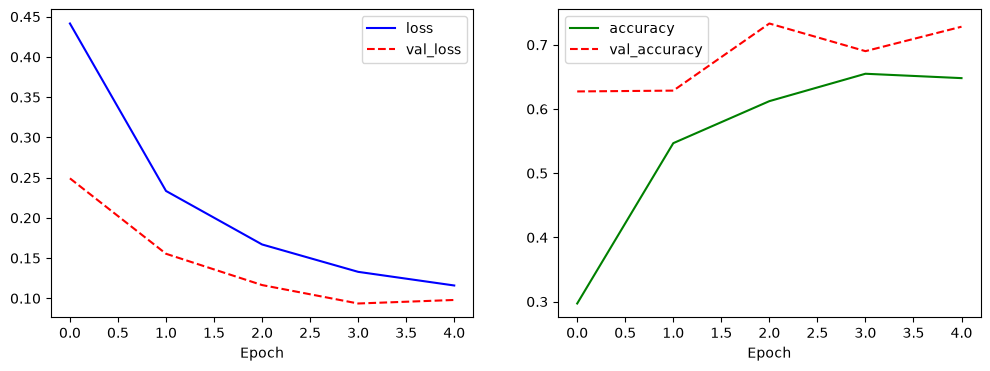

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], 'b-',label='loss')  #b- : blue의 실선
plt.plot(history.history['val_loss'],'r--',label='val_loss')  #r-- :  red의 댓쉬선
plt.xlabel('Epoch')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['acc'], 'g-',label='accuracy')  #g- : green의 실선
plt.plot(history.history['val_acc'],'r--',label='val_accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [25]:
#테스트 데이터로 예측하기
test_datagen = ImageDataGenerator(rescale=1./255) #정규화
test_generator = test_datagen.flow_from_dataframe(
    dataframe = test_df,  #이미지 정보를 가지고 있는 데이터프레임
    directory=None,
    x_col = 'image' ,     #이미지 정보의 컬럼명
    y_col = None,         #정답값은 필요없음
    target_size = (112,112), 
    color_mode = 'rgb',
    class_mode=None,   #레이블 모드. 정답값이 없으므로 필요없음
    batch_size=batch_size, #32개씩 이미지 생성
    shuffle=False   #섞지 않기
)

Found 3416 validated image filenames.


In [ ]:
preds = model.predict(test_generator,steps=32) #steps=32 : 32개씩 꺼내서 예측

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step


In [41]:
preds[:3]
round(preds * 100,2)

TypeError: type numpy.ndarray doesn't define __round__ method

In [37]:
off = 16
do_preds = preds[off:off+8]

100.00 <class 'str'>
100.00 <class 'str'>
99.98 <class 'str'>
100.00 <class 'str'>
99.97 <class 'str'>
99.98 <class 'str'>
100.00 <class 'str'>
100.00 <class 'str'>


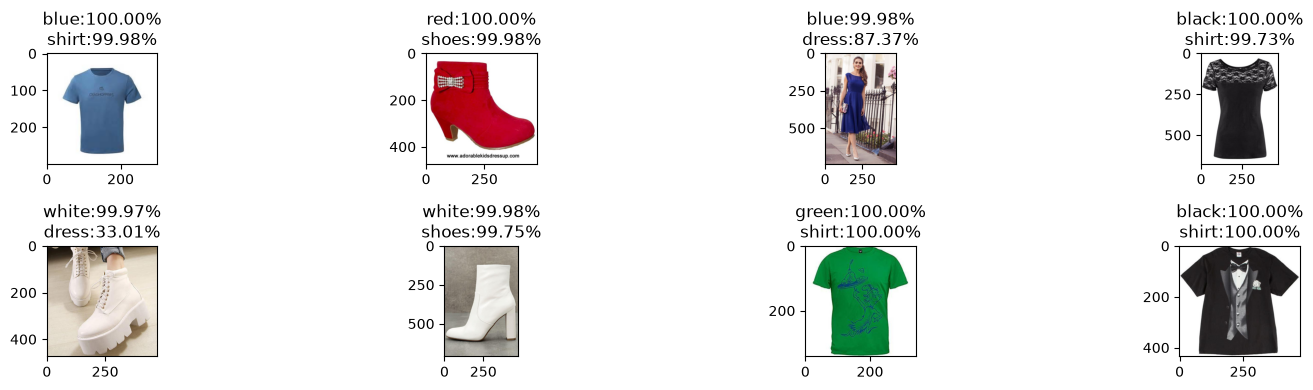

In [52]:
plt.figure(figsize=(20,4))
for i, pred in enumerate(do_preds):
    plt.subplot(2, 4, i + 1) #2행 4열
    #class_col : 레이블 이름
    #pred : 확률값
    prob = zip(class_col,list(pred))
    #prob : (black, 9.99991059e-01),(blue,1.07068104e-07),...
    #sorted : 정렬. 
    # z[1] : 확률값
    prob = sorted(list(prob),key=lambda z : z[1], reverse=True)[:2]  #확률값을 기준으로 내림차순 정렬. 확률이 높은 값 2개만 저장
    #test_df["image"] : 이미지의 이름
    image = plt.imread(test_df["image"][i+off]) #이미지 데이터를 배열로 읽기
    plt.imshow(image) #원본이미지 데이터를 이미지로 출력
    #prob[0][0] : black,... 중 하나의 값. 확률이 가장 높은 레이블
    #prob[0][1] : 확률값중 가장 큰값.
    #prob[1][0] : 레이블값. 확률이 두번쨰로 높은 레이블
    #prob[1][1] : 확률값 중 두번째로 큰값
    #plt.title(f'{prob[0][0]}:{round(prob[0][1] * 100,2)}%\n{prob[1][0]}:{round(prob[1][1] *100,2)}%')
    plt.title(f'{prob[0][0]}:{prob[0][1] * 100:.2f}%\n{prob[1][0]}:{prob[1][1] *100:.2f}%') #이방식으로 처리해야함
    #plt.title(f'{prob[0][0]}:{prob[0][1] * 100}%\n{prob[1][0]}:{prob[1][1] *100}%')
    #print(round(prob[1][1] *100,2),prob[1][1] *100,type(round(prob[1][1] *100,2)),type(prob[1][1] *100))
    print(f'{prob[0][1] * 100:.2f}',type(f'{prob[0][1] * 100:.2f}'))
    plt.tight_layout()              
plt.show()

In [39]:
round(prob[0][1] * 100,2)

np.float32(100.0)

In [ ]:
import tensorflow as tf  
checkpoint_path = 'best_performed_model.weights.h5' #파일의 이름
# 파일 이름의 끝이 반드시 .weights.h5 이어야 함. 
'''
ModelCheckpoint : 학습 모델의 가중치 값을 저장 
checkpoint_path : 파일명
save_weights_only=True : weight(가중치)만 저장
save_weights_only=False : weight(가중치) + 모델데이터 저장
save_best_only=True : 성능이 좋은 경우만 저장
save_best_only=False : 모든 가중치 저장
monitor='val_loss' : 성능 판단 기준. 검증데이터의 손실값을 설정
verbose=1 : 실행과정 출력
'''
checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_path, 
                                                save_weights_only=True, 
                                                save_best_only=True, 
                                                monitor='val_loss',
                                                verbose=1)
# checkpoint :  콜백함수로 사용될 객체. 
# 콜백함수 : 함수에서 호출되는 함수


In [ ]:
#학습 조기 종료 :  모델의 성능이 좋아 지지 않으면 학습 중단
#monitor='val_loss' : 성능 판단 기준. 검증데이터의 손실값을 설정
#patience=2 : 2번의 epoch까지 개선이 되지 않아도 참기. 3번째는 강제 중단
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2)

In [ ]:
history = model.fit(train_generator, steps_per_epoch=get_steps(len(train_df), batch_size),
                    validation_data = val_generator, 
                    validation_steps=get_steps(len(val_df), batch_size),
                    epochs = 10,callbacks=[early_stop, checkpoint])

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 938ms/step - acc: 0.6386 - loss: 0.0981
Epoch 1: val_loss improved from None to 0.08755, saving model to best_performed_model.weights.h5

Epoch 1: finished saving model to best_performed_model.weights.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - acc: 0.6386 - loss: 0.0981 - val_acc: 0.7499 - val_loss: 0.0875
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.6527 - loss: 0.0865
Epoch 2: val_loss did not improve from 0.08755
175/175 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - acc: 0.6527 - loss: 0.0865 - val_acc: 0.5759 - val_loss: 0.0921
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.6452 - loss: 0.0780
Epoch 3: val_loss improved from 0.08755 to 0.08207, saving model to best_performed_model.weights.h5

Epoch 3: finished saving model to best_performed_model.weights.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - acc: 0.6452 - loss: 0.0780 - val_acc: 0.6985 - val_loss: 0.0821
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - ac

In [1]:
# 가중치 파일을 읽기.=> 모델을 저장하지 않았으므로 모델을 생성해야 함
# 모델을 구현하기
# 모델 설정하기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D,MaxPool2D,Dropout
model = Sequential([
    Conv2D(input_shape=(112,112,3),kernel_size=(3,3),filters=32,padding='same',activation='relu'),
    Conv2D(kernel_size=(3,3),filters=64,padding='same',activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Dropout(rate=0.5),  #학습시 50%만 학습. 과적합 해소
    Conv2D(kernel_size=(3,3),filters=128,padding='same',activation='relu'),
    Conv2D(kernel_size=(3,3),filters=256,padding='valid',activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Dropout(rate=0.5),
    
    Flatten(),
    Dense(units=512,activation='relu'),
    Dropout(rate=0.5),
    Dense(units=256,activation='relu'),
    Dropout(rate=0.5),
    Dense(units=11,activation='sigmoid')
])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['acc'])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [2]:
checkpoint_path = 'best_performed_model.weights.h5'

In [3]:
model.load_weights(checkpoint_path)  #모델에 가중치 설정

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(store)


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
test_df = pd.read_csv('./archive/test.csv')
#테스트 데이터로 예측하기
test_datagen = ImageDataGenerator(rescale=1./255) #정규화
test_generator = test_datagen.flow_from_dataframe(
    dataframe = test_df,  #이미지 정보를 가지고 있는 데이터프레임
    directory=None,
    x_col = 'image' ,     #이미지 정보의 컬럼명
    y_col = None,         #정답값은 필요없음
    target_size = (112,112), 
    color_mode = 'rgb',
    class_mode=None,   #레이블 모드. 정답값이 없으므로 필요없음
    batch_size=32, #32개씩 이미지 생성
    shuffle=False   #섞지 않기
)

Found 3416 validated image filenames.


In [5]:
preds = model.predict(test_generator,steps=32)

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 221ms/step


In [15]:
off = 24
do_preds = preds[off:off+8]

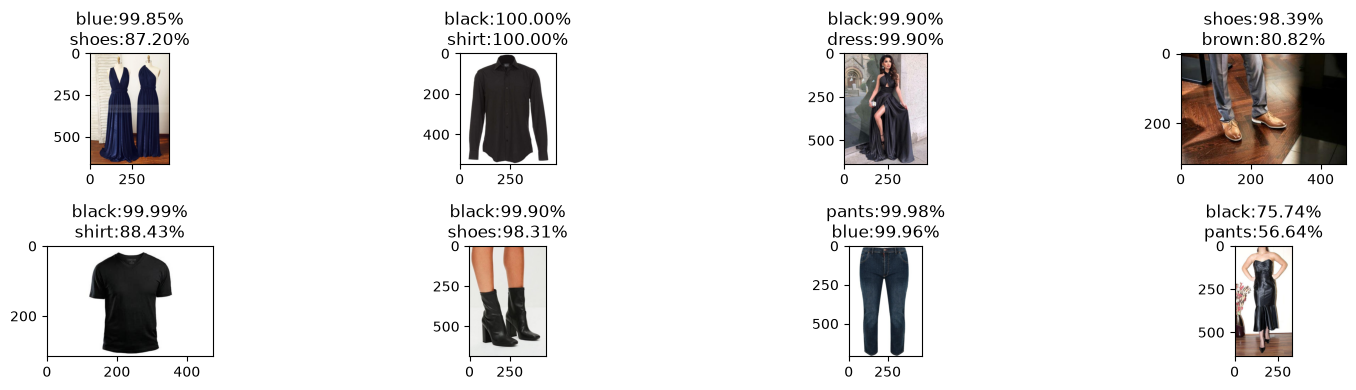

In [16]:
import matplotlib.pyplot as plt
class_col = ['black', 'blue', 'brown', 'green', 'red', 'white','dress',  'shirt', 'pants', 'shorts', 'shoes']
plt.figure(figsize=(20,4))
for i, pred in enumerate(do_preds):
    plt.subplot(2, 4, i + 1) #2행 4열
    prob = zip(class_col,list(pred))
    prob = sorted(list(prob),key=lambda z : z[1], reverse=True)[:2]  #확률값을 기준으로 내림차순 정렬. 확률이 높은 값 2개만 저장
    image = plt.imread(test_df["image"][i+off]) #이미지 데이터를 배열로 읽기
    plt.imshow(image) #원본이미지 데이터를 이미지로 출력
    plt.title(f'{prob[0][0]}:{prob[0][1] * 100:.2f}%\n{prob[1][0]}:{prob[1][1] *100:.2f}%') #이방식으로 처리해야함
    plt.tight_layout()              
plt.show()

In [ ]:
#데이터 증식 방법 : 이미지를 변경하여 생성. 학습 데이터가 부족한 경우.
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
#데이터 증식 방법 설정 
train_datagen = ImageDataGenerator(horizontal_flip = True, #수평방향으로 뒤집기
                                   vertical_flip = True,   #수직방향으로 뒤집기
                                   shear_range=0.5,        #시계방향으로 이미지 밀기
                                   brightness_range=[0.5,1.0], #이미지 밝기 조정
                                   zoom_range=0.2,         #이미지 크기 확대/축소 
                                   width_shift_range=0.1,  #가로 방향 이동 
                                   height_shift_range=0.1, #세로 방향 이동 
                                   rotation_range=30,      #이미지 회전 
                                   fill_mode='nearest')    #이미지 변환시 픽셀 채우는 방법 


In [17]:

import tensorflow as tf
image_path = tf.keras.utils.get_file('cat.jpg','http://bit.ly/33U6mH9')
image=plt.imread(image_path)
image.shape


(241, 320, 3)

In [ ]:

image = image.reshape((1,) + image.shape) #차수를 증가시킴
image.shape


(1, 241, 320, 3)

In [ ]:
#train_datagen 객체 설정된 내용대로 이미지를 한장씩 생성
train_generator = train_datagen.flow(image,batch_size=1)


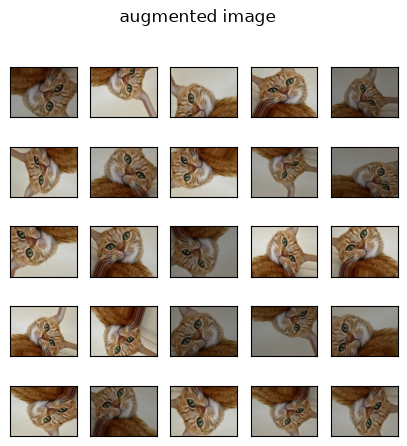

In [20]:

fig = plt.figure(figsize=(5,5))
fig.suptitle("augmented image")
for i in range(25) : 
   data = next(train_generator) #train_generator에서 이미지 한개를 받아옴 
   image = data[0] 
   plt.subplot(5, 5, i+1)
   plt.xticks([])
   plt.yticks([])
   plt.imshow(np.array(image, dtype = np.uint8), cmap = 'gray')    
plt.show()
